In [1]:
from collections import namedtuple
from itertools import batched, chain
import json
import math
from multiprocessing import Pool
from pathlib import Path

from datasets import load_from_disk
import matplotlib.pyplot as plt
from nltk.stem.snowball import SnowballStemmer
import numpy as np
import pandas as pd
from scipy import stats
import seaborn as sns
from tqdm.notebook import tqdm
from transformers import AutoTokenizer

from genai_detection.detectors.ppmd import PPMdDetector
from genai_detection.detectors.unmasking import UnmaskingDetector

In [2]:
sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 300
plt.rcParams['font.family'] = 'Helvetica, sans-serif'
plt.rcParams['font.size'] = 6.5
plt.rcParams['lines.linewidth'] = .5
plt.rcParams['axes.linewidth'] = .5
plt.rcParams['grid.linewidth'] = .25

In [58]:
bytepair_tokenizer = AutoTokenizer.from_pretrained('gpt2', truncation=False, max_length=None, model_max_length=None)


def tokenize_bytepair(text):
    return bytepair_tokenizer.tokenize(text)


def normalize_text(text):
    stemmer = SnowballStemmer('english')
    return ' '.join(stemmer.stem(w) for w in text.lower().split())


def sample_texts(h, m, min_text_ln=3000, n_texts=30, seed=42):
    h = h.query('text.str.len() >= @min_text_ln')
    h = h.sample(n=min(h['id'].count(), n_texts), random_state=seed)

    m = {k: v.query('text.str.len() >= @min_text_ln') for k, v in m.items()}
    m = {k: v.sample(n=min(n_texts, v['id'].count()), random_state=seed) for k, v in m.items()}

    return h, m

def _label_curve_pairings(curves, pairing_label):
    curves = pd.DataFrame({f'{pairing_label} ({i:04})': c for i, c in enumerate(curves)})
    curves['pairing'] = pairing_label
    return curves


def unmask(texts_h, texts_m, **unmasking_kwargs):
    unmask_det = UnmaskingDetector(strict=True, **unmasking_kwargs)

    with Pool() as pool:
        th = texts_h['text'].map(normalize_text)
        th = th.iloc[:len(th) // 2 * 2]     # Ensure rows are a multiple of two
        l = 'Human / Human'
        curves_h = tqdm(pool.imap(unmask_det.get_curves, batched(th, n=2)), desc=f'Unmasking {l}', total=len(th) // 2)
        curves_h = _label_curve_pairings(np.squeeze(list(curves_h), axis=1), 'Human / Human')

        curves_m = []
        curves_hm = []
        machine_names = list(texts_m.keys())
        for i, tm in enumerate(texts_m.values()):
            tm = tm['text'].map(normalize_text).iloc[:len(tm) // 2 * 2]
            l = f'{machine_names[i]} / {machine_names[i]}'
            cm = list(tqdm(pool.imap(unmask_det.get_curves, batched(tm, n=2)), desc=f'Unmasking {l}', total=len(tm) // 2))
            curves_m.append(_label_curve_pairings(np.squeeze(list(cm), axis=1), l))

            n = min(len(th), len(tm)) // 2
            l = f'Human / {machine_names[i]}'
            it = zip(th[:n], tm[:n])
            chm = list(tqdm(pool.imap(unmask_det.get_curves, it), desc=f'Unmasking {l}', total=n))
            curves_hm.append(_label_curve_pairings(np.squeeze(list(chm), axis=1), l))

        curves = pd.concat([curves_h, *curves_m, *curves_hm])
        curves = pd.melt(curves, var_name='curve_id', value_name='accuracy', id_vars=['pairing'], ignore_index=False)
        curves = curves.reset_index(drop=False, names='round')

    return curves


def compress(texts_h, texts_m):
    comp_det = PPMdDetector()

    scores = [('Human / Human', 1.0 - s) for s in comp_det.get_score(tqdm(texts_h['text'], desc='Compressing Human / Human'))]

    machine_names = list(texts_m.keys())
    for i, tm in enumerate(texts_m.values()):
        l = f'{machine_names[i]} / {machine_names[i]}'
        it = tqdm(texts_m[machine_names[i]]['text'], desc=f'Compressing {l}')
        scores.extend([(l, 1.0 - s) for s in comp_det.get_score(it)])

        l = f'Human / {machine_names[i]}'
        n = min(len(texts_h['text']), len(tm)) // 2
        it = chain(*zip(texts_h['text'][:n].map(normalize_text), tm['text'][:n].map(normalize_text)))
        it = tqdm(it, desc=f'Compressing {l}', total=n * 2)
        scores.extend([(l, 1.0 - s) for s in comp_det.get_score(it)])

    return pd.DataFrame(scores, columns=['pairing', 'score'])


def plot_unmasking_curves(curves, max_cols=4, errorbar=('ci', 95), title=None, savefig=None):
    machines = [m.split(' / ', 1)[0] for m in curves['pairing'].unique() if 'Human' not in m]
    n_cols = min(max_cols, len(machines))
    n_rows = int(math.ceil(len(machines) / max_cols))
    pal = sns.color_palette('husl', 3)

    title_y = .93 if n_rows == 1 else .97
    v_factor = 1.5 if n_rows == 1 else 1.25
    fig, axs = plt.subplots(n_rows, n_cols, figsize=(1.4 * n_cols, n_rows * v_factor), sharex=True, sharey=True)

    for i in range(n_cols * n_rows):
        ax = axs.flat[i]
        if i < len(machines):
            p = ['Human / Human', f'{machines[i]} / {machines[i]}', f'Human / {machines[i]}']
            _ = p   # Mark used
            c = curves.query('pairing in @p')
            sns.lineplot(c, x='round', y='accuracy', hue='pairing', style='pairing', palette=pal, errorbar=errorbar, ax=ax)
            ax.legend(title=None, frameon=False, borderaxespad=.15, loc='lower left', fontsize='x-small')
        ax.set_ylim((.5, 1.0))
        ax.set_yticks((.6, .7, .8, .9, 1.0))
        ax.set_xlim((0, curves['round'].max()))
        ax.set_xlabel('Unmasking Rounds')
        if i % max_cols == 0:
            ax.set_ylabel('Accuracy')

    if title:
        fig.suptitle(title, fontsize=plt.rcParams['font.size'], fontweight='bold', ha='left', x=0.076, y=title_y)
    plt.tight_layout(pad=0.8)
    plt.subplots_adjust(wspace=.025, hspace=.025)
    if savefig:
        Path(savefig).parent.mkdir(parents=True, exist_ok=True)
        plt.savefig(savefig)
    plt.show()


def plot_compression(scores, max_cols=4, title=None, savefig=None):
    machines = [m.split(' / ', 1)[0] for m in scores['pairing'].unique() if 'Human' not in m]
    n_cols = min(max_cols, len(machines))
    n_rows = int(math.ceil(len(machines) / max_cols))
    pal = sns.color_palette('husl', 3)

    title_y = .93 if n_rows == 1 else .97
    v_factor = 1.5 if n_rows == 1 else 1.25
    fig, axs = plt.subplots(n_rows, n_cols, figsize=(1.4 * n_cols, n_rows * v_factor), sharex=True, sharey=True)

    for i in range(n_cols * n_rows):
        ax = axs.flat[i]
        if i < len(machines):
            p = ['Human / Human', f'{machines[i]} / {machines[i]}', f'Human / {machines[i]}']
            for i_, p_ in enumerate(p):
                sns.kdeplot(scores.query('pairing == @p_')['score'], color=pal[i_], label=p_, ax=ax)
            ax.legend(p, title=None, frameon=False, borderaxespad=.15, loc='upper left', fontsize='x-small')
        ax.set_xlabel('CBC Score')
        if i % max_cols == 0:
            ax.set_ylabel('Density')

    if title:
        fig.suptitle(title, fontsize=plt.rcParams['font.size'], fontweight='bold', ha='left', x=.072, y=title_y)
    plt.tight_layout(pad=0.8)
    plt.subplots_adjust(wspace=.025, hspace=.05)
    if savefig:
        Path(savefig).parent.mkdir(parents=True, exist_ok=True)
        plt.savefig(savefig)
    plt.show()


TTestResult = namedtuple('TTestResult', ['t', 'dof', 'p', 'd'])


def t_test(a, b):
    t, p = stats.ttest_ind(a, b)
    d = t * np.sqrt((len(a) + len(b)) / (len(a) * len(b)))
    return TTestResult(t=t, dof=len(a) + len(b) - 2, p=p, d=d)


def t_test_str(t: TTestResult, correction_factor=1):
    p_str = f'< {.001:>5}' if t.p < .001 else f'= {t.p:>5,.3f}'
    if correction_factor:
        p_corr = t.p * correction_factor
        if p_corr >= 1.:
            p_str += ', p[bf] = 1.00'
        else:
            p_str += ', p[bf] ' + (f'< {.001:>5}' if p_corr < .001 else f'= {p_corr:>5,.3f}')
    return f't({t.dof:,}) = {t.t:>6,.2f}, p {p_str.replace('0.', '.')}, d = {t.d:>4,.1f}'


def print_t_test_for_curves(curves, min_round=10):
    pairings = [p for p in curves['pairing'].unique() if not p.startswith('Human /')]
    print('Differences from Human / Human:')
    for pairing in pairings:
        t = t_test(curves.query('round >= @min_round and pairing == "Human / Human"')['accuracy'].dropna(),
                   curves.query('round >= @min_round and pairing == @pairing')['accuracy'].dropna())
        print(f'  {pairing:<{max(len(p_) for p_ in pairings) + 1}}: {t_test_str(t, len(pairings))}')


def print_t_test_for_compression(cbc):
    pairings = [p for p in cbc['pairing'].unique() if not p.startswith('Human /')]
    print('Differences from Human / Human:')
    for pairing in pairings:
        t = t_test(cbc.query('pairing == "Human / Human"')['score'],
                   cbc.query('pairing == @pairing')['score'])
        print(f'  {pairing:<{max(len(p_) for p_ in pairings) + 1}}: {t_test_str(t, len(pairings))}')

### PAN

In [4]:
def split_pan_ds_dataset_by_model(df, seed=42):
    df_human = df.query('model == "human"').sample(frac=1, random_state=seed)
    df_machine = {
        'Qwen1.5-72b': df.query('model == "qwen1.5-72b-chat-8bit"').sample(frac=1, random_state=seed),
        'Mistral-7b': df.query('model == "mistral-7b-instruct-v0.2"').sample(frac=1, random_state=seed),
        'Llama2-7b': df.query('model == "llama-2-7b-chat"').sample(frac=1, random_state=seed),
        'Llama2-70b': df.query('model == "llama-2-70b-chat"').sample(frac=1, random_state=seed),
        'PaLM2': df.query('model == "text-bison-002"').sample(frac=1, random_state=seed),
        'Gemini Pro': df.query('model == "gemini-pro"').sample(frac=1, random_state=seed),
        'GPT-3.5 Turbo': df.query('model == "gpt-3.5-turbo"').sample(frac=1, random_state=seed),
        'GPT-4 Turbo': df.query('model == "gpt-4-turbo"').sample(frac=1, random_state=seed),
        'GPT-4o': df.query('model == "gpt-4o"').sample(frac=1, random_state=seed),
        'OpenAI o1': df.query('model == "openai-o1"').sample(frac=1, random_state=seed),
    }
    return df_human, df_machine


ds_pan = load_from_disk('../data/datasets/pan24-extended-converted')['train'].to_pandas()
print('Unique Models:', list(ds_pan['model'].unique()))
df_pan_h, df_pan_m = split_pan_ds_dataset_by_model(ds_pan)

# Expand gnews meta data
tmp = []
for i, r in df_pan_h.iterrows():
    j = json.loads(r['gnews_meta'])
    for k, v in j.items():
        r[f'gnews_{k}'] = v
    del r['gnews_meta']
    tmp.append(r)
df_pan_h = pd.DataFrame(tmp)
del tmp

assert df_pan_h['label'].count() > 0 and df_pan_h['label'].sum() == 0

sample_pan = sample_texts(df_pan_h, df_pan_m, n_texts=400)

Unique Models: ['qwen1.5-72b-chat-8bit', 'gemini-pro-paraphrase', 'gpt-4-turbo', 'openai-o1', 'llama-2-13b-chat-contrastive-0.1', 'llama-2-70b-chat', 'human', 'mistral-7b-instruct-v0.2', 'gpt-4o-mini', 'llama-2-13b-chat-contrastive-0.6', 'bigscience-bloomz-7b1', 'text-bison-002', 'gpt-3.5-turbo', 'gpt-4o', 'mixtral-8x7b-instruct-v0.1', 'gpt-4-turbo-paraphrase', 'gemini-pro', 'llama-2-7b-chat']


In [5]:
curves_pan_top_250 = unmask(*sample_pan, top_n=250, n_delete=4, rounds=25, shared_vocab_only=True)

Unmasking Human / Human:   0%|          | 0/200 [00:00<?, ?it/s]

Unmasking Qwen1.5-72b / Qwen1.5-72b:   0%|          | 0/101 [00:00<?, ?it/s]

Unmasking Human / Qwen1.5-72b:   0%|          | 0/101 [00:00<?, ?it/s]

Unmasking Mistral-7b / Mistral-7b:   0%|          | 0/200 [00:00<?, ?it/s]

Unmasking Human / Mistral-7b:   0%|          | 0/200 [00:00<?, ?it/s]

...

Unmasking Human / GPT-4 Turbo:   0%|          | 0/200 [00:00<?, ?it/s]

Unmasking GPT-4o / GPT-4o:   0%|          | 0/200 [00:00<?, ?it/s]

Unmasking Human / GPT-4o:   0%|          | 0/200 [00:00<?, ?it/s]

Unmasking OpenAI o1 / OpenAI o1:   0%|          | 0/200 [00:00<?, ?it/s]

Unmasking Human / OpenAI o1:   0%|          | 0/200 [00:00<?, ?it/s]

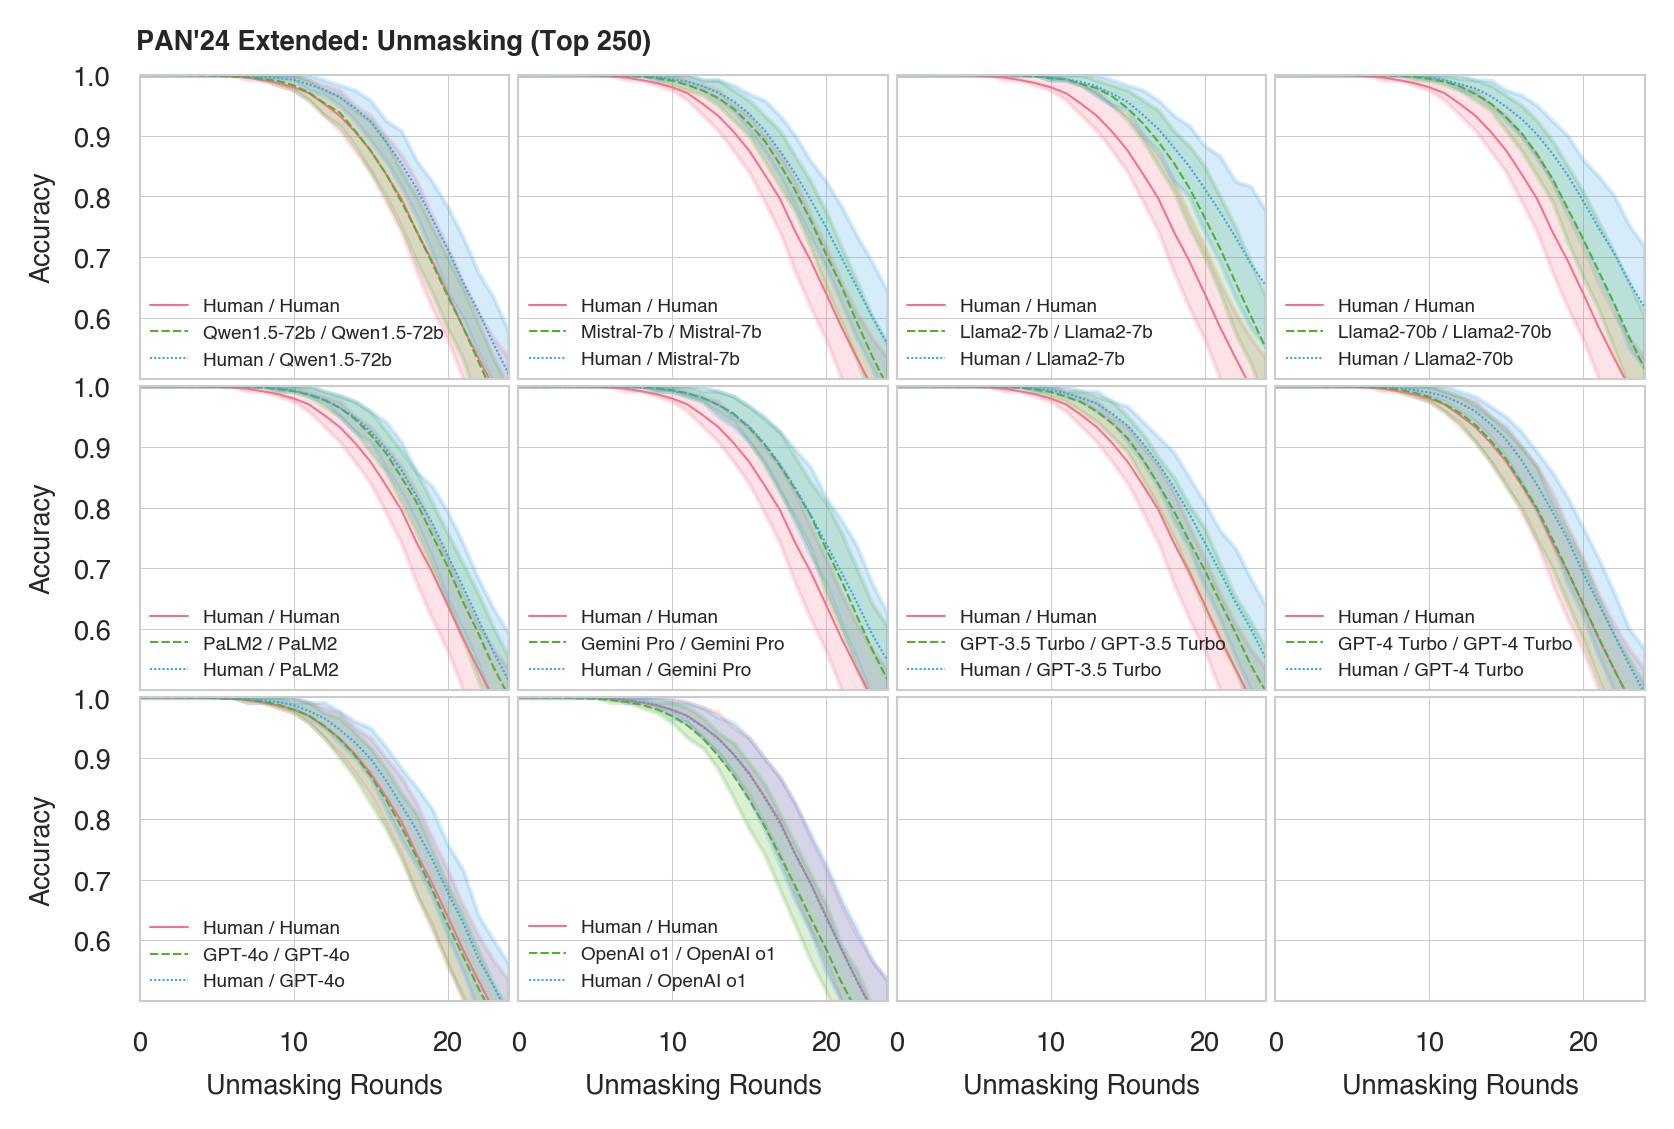

In [59]:
plot_unmasking_curves(curves_pan_top_250, errorbar=('pi', 50), title='PAN\'24 Extended: Unmasking (Top 250)', savefig='../data/figures/unmasking-curves-pan-250.pdf')

In [7]:
curves_pan_top_500 = unmask(*sample_pan, top_n=500, n_delete=8, rounds=25, shared_vocab_only=True)

Unmasking Human / Human:   0%|          | 0/200 [00:00<?, ?it/s]

Unmasking Qwen1.5-72b / Qwen1.5-72b:   0%|          | 0/101 [00:00<?, ?it/s]

Unmasking Human / Qwen1.5-72b:   0%|          | 0/101 [00:00<?, ?it/s]

Unmasking Mistral-7b / Mistral-7b:   0%|          | 0/200 [00:00<?, ?it/s]

Unmasking Human / Mistral-7b:   0%|          | 0/200 [00:00<?, ?it/s]

...

Unmasking Human / GPT-4 Turbo:   0%|          | 0/200 [00:00<?, ?it/s]

Unmasking GPT-4o / GPT-4o:   0%|          | 0/200 [00:00<?, ?it/s]

Unmasking Human / GPT-4o:   0%|          | 0/200 [00:00<?, ?it/s]

Unmasking OpenAI o1 / OpenAI o1:   0%|          | 0/200 [00:00<?, ?it/s]

Unmasking Human / OpenAI o1:   0%|          | 0/200 [00:00<?, ?it/s]

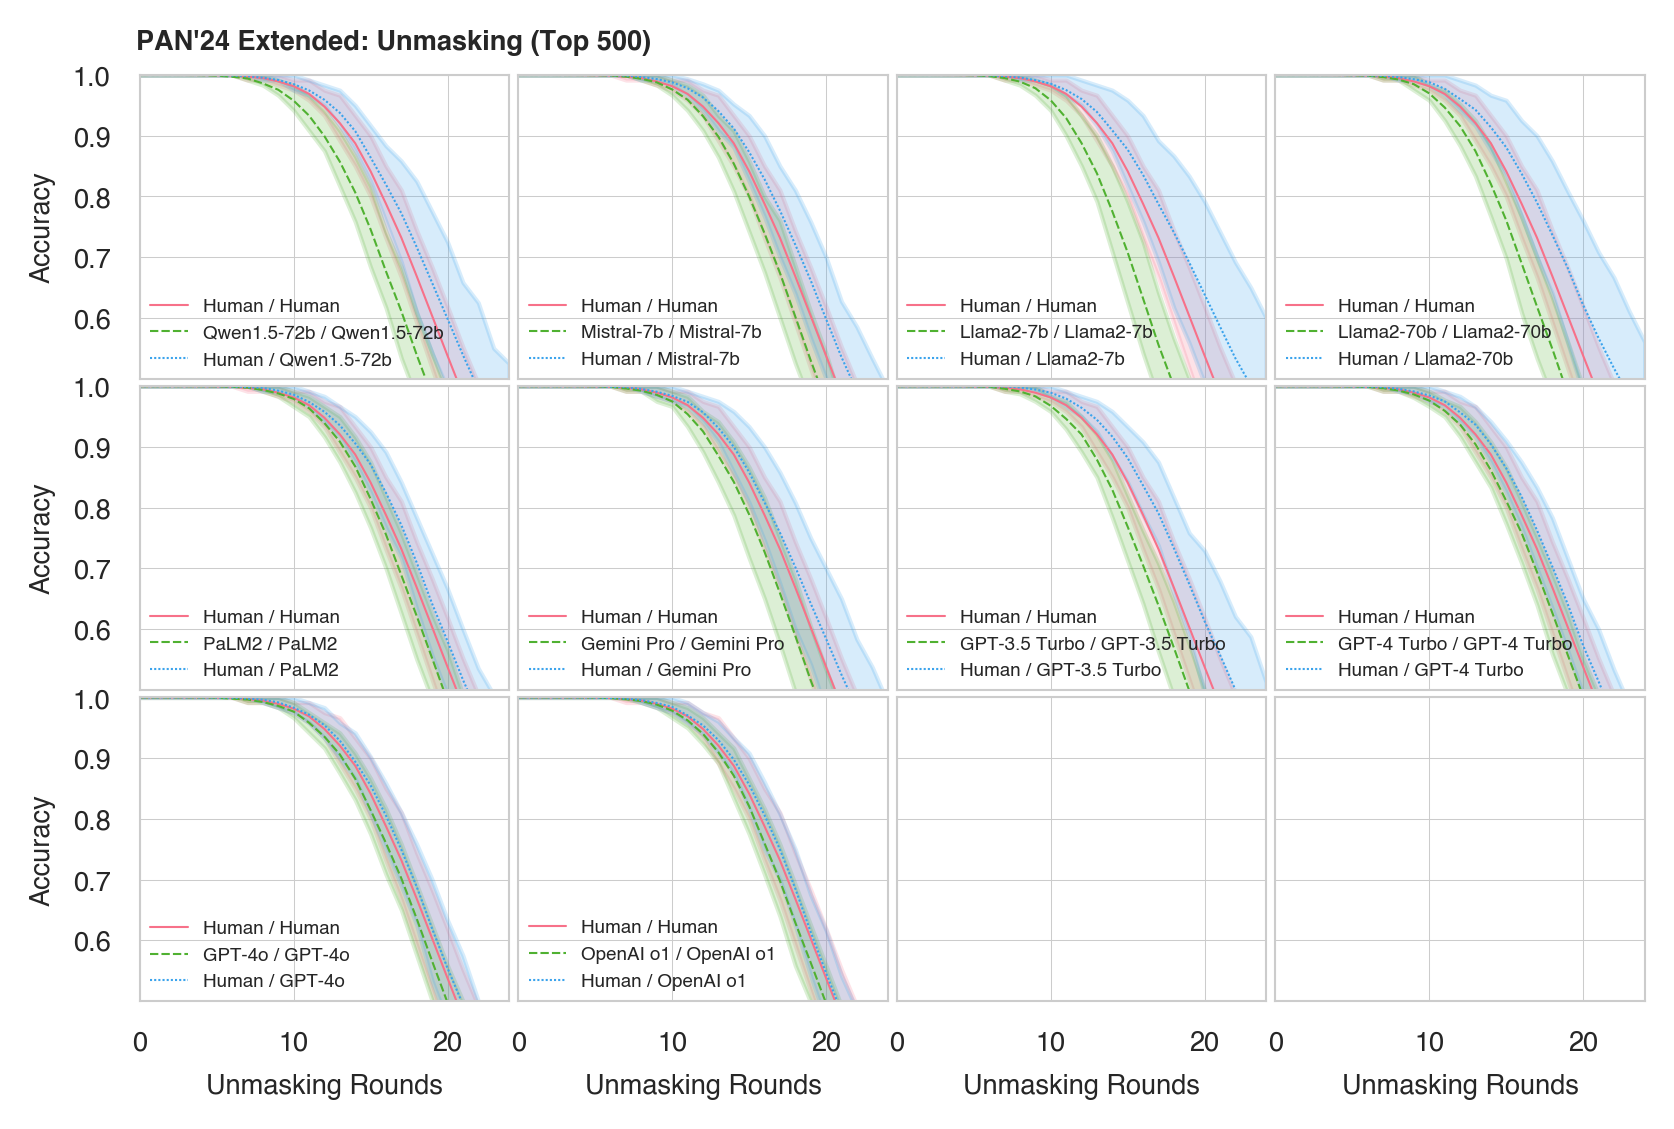

In [60]:
plot_unmasking_curves(curves_pan_top_500, errorbar=('pi', 50), title='PAN\'24 Extended: Unmasking (Top 500)', savefig='../data/figures/unmasking-curves-pan-500.pdf')

In [9]:
print_t_test_for_curves(curves_pan_top_500)

Differences from Human / Human:
  Qwen1.5-72b / Qwen1.5-72b     : t(4,513) =  12.32, p < .001, p[bf] < .001, d =  0.4
  Mistral-7b / Mistral-7b       : t(5,998) =   7.61, p < .001, p[bf] < .001, d =  0.2
  Llama2-7b / Llama2-7b         : t(5,053) =  16.40, p < .001, p[bf] < .001, d =  0.5
  Llama2-70b / Llama2-70b       : t(5,998) =  12.74, p < .001, p[bf] < .001, d =  0.3
  PaLM2 / PaLM2                 : t(5,998) =   5.43, p < .001, p[bf] < .001, d =  0.1
  Gemini Pro / Gemini Pro       : t(5,983) =   8.81, p < .001, p[bf] < .001, d =  0.2
  GPT-3.5 Turbo / GPT-3.5 Turbo : t(4,963) =  10.01, p < .001, p[bf] < .001, d =  0.3
  GPT-4 Turbo / GPT-4 Turbo     : t(5,998) =   5.09, p < .001, p[bf] < .001, d =  0.1
  GPT-4o / GPT-4o               : t(5,998) =   4.34, p < .001, p[bf] < .001, d =  0.1
  OpenAI o1 / OpenAI o1         : t(5,998) =   4.21, p < .001, p[bf] < .001, d =  0.1


In [10]:
cbc_pan = compress(*sample_pan)

Compressing Human / Human:   0%|          | 0/400 [00:00<?, ?it/s]

Compressing Qwen1.5-72b / Qwen1.5-72b:   0%|          | 0/202 [00:00<?, ?it/s]

Compressing Human / Qwen1.5-72b:   0%|          | 0/202 [00:00<?, ?it/s]

Compressing Mistral-7b / Mistral-7b:   0%|          | 0/400 [00:00<?, ?it/s]

Compressing Human / Mistral-7b:   0%|          | 0/400 [00:00<?, ?it/s]

...

Compressing Human / GPT-4 Turbo:   0%|          | 0/400 [00:00<?, ?it/s]

Compressing GPT-4o / GPT-4o:   0%|          | 0/400 [00:00<?, ?it/s]

Compressing Human / GPT-4o:   0%|          | 0/400 [00:00<?, ?it/s]

Compressing OpenAI o1 / OpenAI o1:   0%|          | 0/400 [00:00<?, ?it/s]

Compressing Human / OpenAI o1:   0%|          | 0/400 [00:00<?, ?it/s]

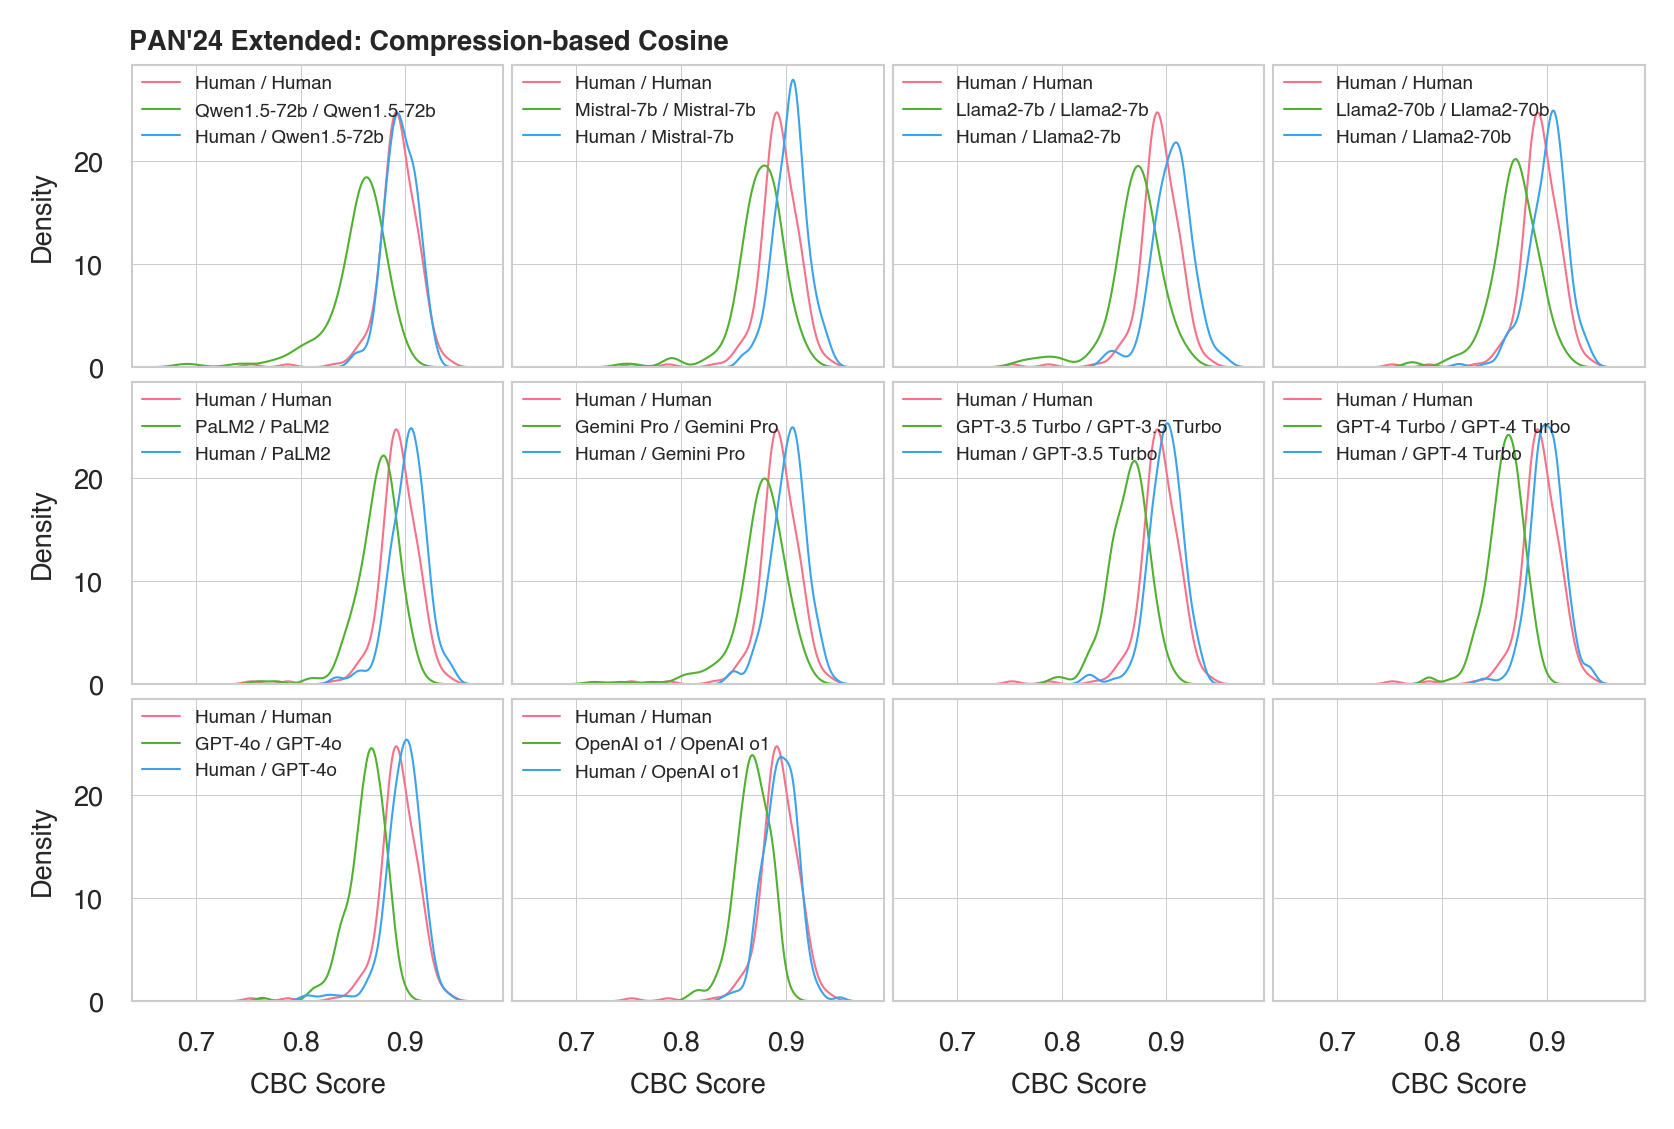

In [61]:
plot_compression(cbc_pan, title='PAN\'24 Extended: Compression-based Cosine', savefig='../data/figures/unmasking-compression-pan.pdf')

In [12]:
print_t_test_for_compression(cbc_pan)

Differences from Human / Human:
  Qwen1.5-72b / Qwen1.5-72b     : t(299) =  13.17, p < .001, p[bf] < .001, d =  1.6
  Mistral-7b / Mistral-7b       : t(398) =   7.84, p < .001, p[bf] < .001, d =  0.8
  Llama2-7b / Llama2-7b         : t(335) =   8.99, p < .001, p[bf] < .001, d =  1.0
  Llama2-70b / Llama2-70b       : t(398) =  10.89, p < .001, p[bf] < .001, d =  1.1
  PaLM2 / PaLM2                 : t(398) =   9.26, p < .001, p[bf] < .001, d =  0.9
  Gemini Pro / Gemini Pro       : t(397) =   7.31, p < .001, p[bf] < .001, d =  0.7
  GPT-3.5 Turbo / GPT-3.5 Turbo : t(329) =  12.96, p < .001, p[bf] < .001, d =  1.5
  GPT-4 Turbo / GPT-4 Turbo     : t(398) =  17.10, p < .001, p[bf] < .001, d =  1.7
  GPT-4o / GPT-4o               : t(398) =  15.49, p < .001, p[bf] < .001, d =  1.5
  OpenAI o1 / OpenAI o1         : t(398) =  13.33, p < .001, p[bf] < .001, d =  1.3


### Human Detectors

In [13]:
def split_hd_ds_dataset_by_model(df, seed=42):
    df_human = df.query('model == "human"').sample(frac=1, random_state=seed)
    df_machine = {
        'Claude': df.query('model == "claude"').sample(frac=1, random_state=seed),
        'GPT-4o': df.query('model == "gpt-4o"').sample(frac=1, random_state=seed),
        'o1': df.query('model == "o1-pro"').sample(frac=1, random_state=seed),
        'Hum. o1': df.query('model == "humanized_o1-pro"').sample(frac=1, random_state=seed),
    }
    return df_human, df_machine


ds_hd = load_from_disk('../data/datasets/human-detectors-converted')['train'].to_pandas()
display(ds_hd['model'].unique())
df_hd_h, df_hd_m = split_hd_ds_dataset_by_model(ds_hd)
assert df_hd_h['label'].count() > 0 and df_hd_h['label'].sum() == 0

sample_hd = sample_texts(df_hd_h, df_hd_m, n_texts=30)

array(['paraphrased_gpt-4o', 'gpt-4o', 'human', 'o1-pro', 'claude',
       'humanized_o1-pro'], dtype=object)

In [14]:
curves_hd_top_250 = unmask(*sample_hd, top_n=250, n_delete=4, rounds=25, shared_vocab_only=True)

Unmasking Human / Human:   0%|          | 0/15 [00:00<?, ?it/s]

Unmasking Claude / Claude:   0%|          | 0/10 [00:00<?, ?it/s]

Unmasking Human / Claude:   0%|          | 0/10 [00:00<?, ?it/s]

Unmasking GPT-4o / GPT-4o:   0%|          | 0/9 [00:00<?, ?it/s]

Unmasking Human / GPT-4o:   0%|          | 0/9 [00:00<?, ?it/s]

Unmasking o1 / o1:   0%|          | 0/10 [00:00<?, ?it/s]

Unmasking Human / o1:   0%|          | 0/10 [00:00<?, ?it/s]

Unmasking Hum. o1 / Hum. o1:   0%|          | 0/10 [00:00<?, ?it/s]

Unmasking Human / Hum. o1:   0%|          | 0/10 [00:00<?, ?it/s]

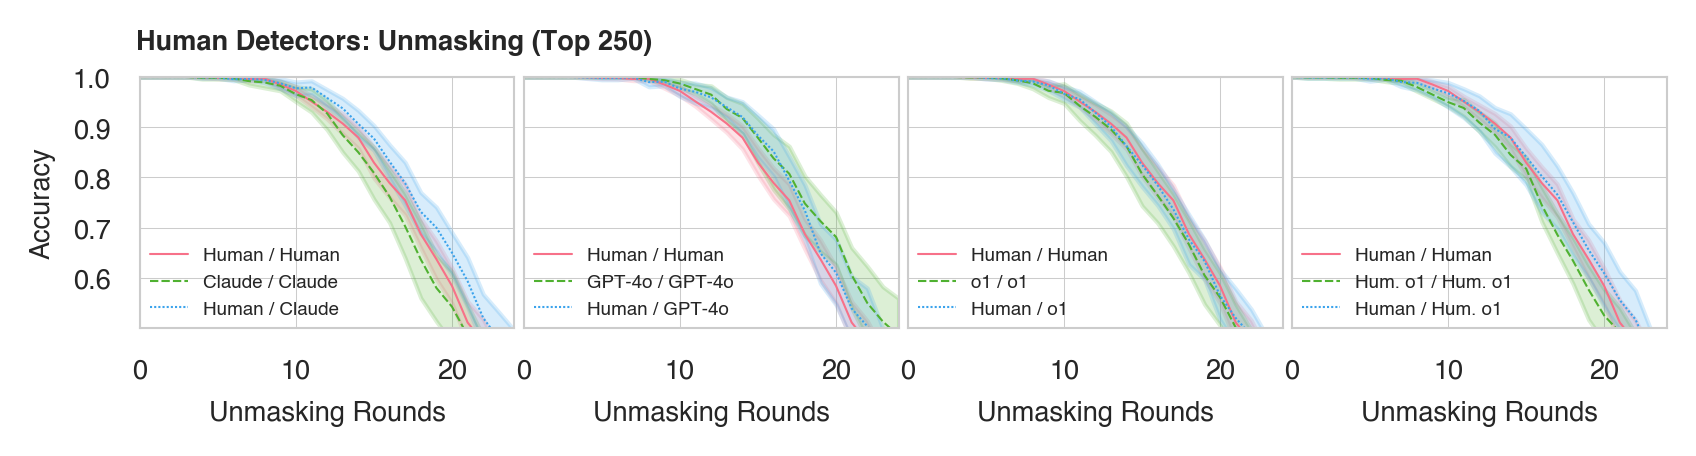

In [62]:
plot_unmasking_curves(curves_hd_top_250, errorbar=('ci', 95), title='Human Detectors: Unmasking (Top 250)', savefig='../data/figures/unmasking-curves-hd-250.pdf')

In [16]:
curves_hd_top_500 = unmask(*sample_hd, top_n=500, n_delete=8, rounds=25, shared_vocab_only=True)

Unmasking Human / Human:   0%|          | 0/15 [00:00<?, ?it/s]

Unmasking Claude / Claude:   0%|          | 0/10 [00:00<?, ?it/s]

Unmasking Human / Claude:   0%|          | 0/10 [00:00<?, ?it/s]

Unmasking GPT-4o / GPT-4o:   0%|          | 0/9 [00:00<?, ?it/s]

Unmasking Human / GPT-4o:   0%|          | 0/9 [00:00<?, ?it/s]

Unmasking o1 / o1:   0%|          | 0/10 [00:00<?, ?it/s]

Unmasking Human / o1:   0%|          | 0/10 [00:00<?, ?it/s]

Unmasking Hum. o1 / Hum. o1:   0%|          | 0/10 [00:00<?, ?it/s]

Unmasking Human / Hum. o1:   0%|          | 0/10 [00:00<?, ?it/s]

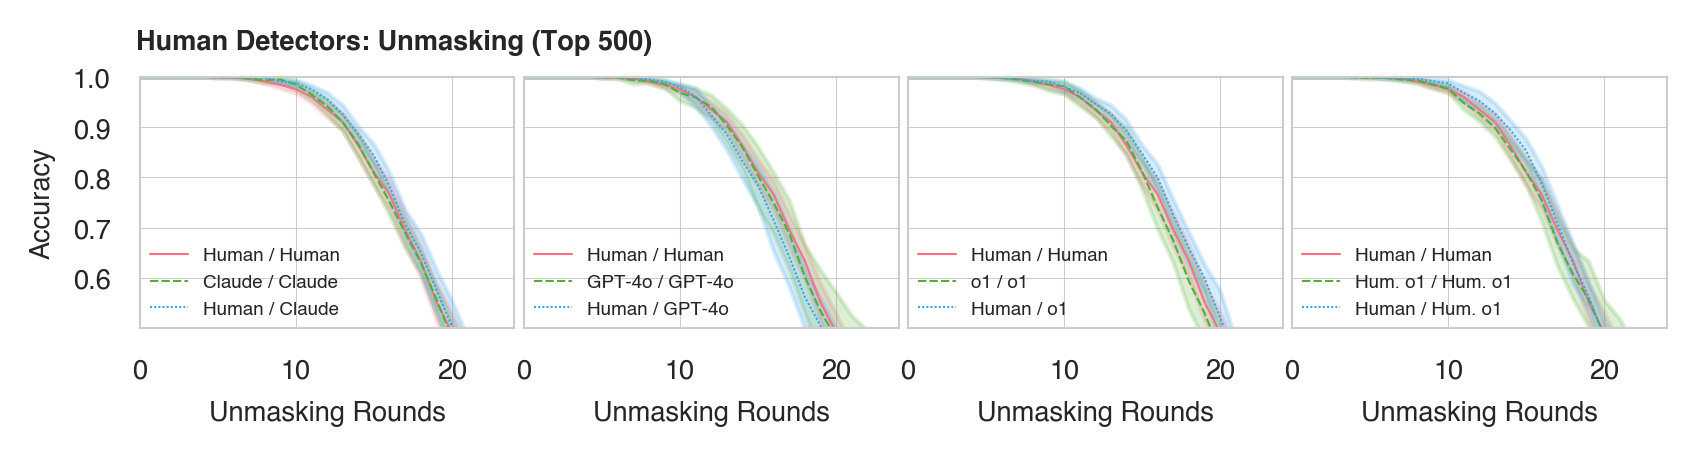

In [63]:
plot_unmasking_curves(curves_hd_top_500, errorbar=('ci', 95), title='Human Detectors: Unmasking (Top 500)', savefig='../data/figures/unmasking-curves-hd-500.pdf')

In [18]:
print_t_test_for_curves(curves_hd_top_500)

Differences from Human / Human:
  Claude / Claude   : t(373) =   0.12, p = .908, p[bf] = 1.00, d =  0.0
  GPT-4o / GPT-4o   : t(358) =  -0.04, p = .970, p[bf] = 1.00, d = -0.0
  o1 / o1           : t(373) =   0.61, p = .540, p[bf] = 1.00, d =  0.1
  Hum. o1 / Hum. o1 : t(373) =   0.16, p = .875, p[bf] = 1.00, d =  0.0


In [19]:
cbc_hd = compress(*sample_hd)

Compressing Human / Human:   0%|          | 0/30 [00:00<?, ?it/s]

Compressing Claude / Claude:   0%|          | 0/20 [00:00<?, ?it/s]

Compressing Human / Claude:   0%|          | 0/20 [00:00<?, ?it/s]

Compressing GPT-4o / GPT-4o:   0%|          | 0/19 [00:00<?, ?it/s]

Compressing Human / GPT-4o:   0%|          | 0/18 [00:00<?, ?it/s]

Compressing o1 / o1:   0%|          | 0/21 [00:00<?, ?it/s]

Compressing Human / o1:   0%|          | 0/20 [00:00<?, ?it/s]

Compressing Hum. o1 / Hum. o1:   0%|          | 0/20 [00:00<?, ?it/s]

Compressing Human / Hum. o1:   0%|          | 0/20 [00:00<?, ?it/s]

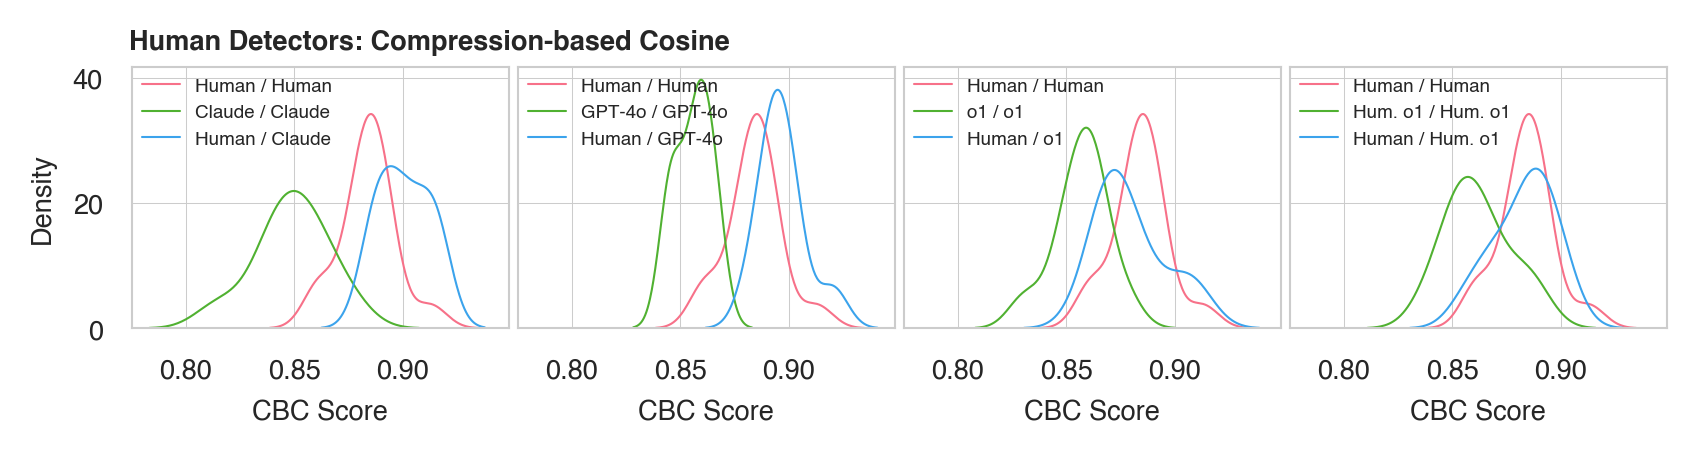

In [64]:
plot_compression(cbc_hd, title='Human Detectors: Compression-based Cosine', savefig='../data/figures/unmasking-compression-hd.pdf')

In [21]:
print_t_test_for_compression(cbc_hd)

Differences from Human / Human:
  Claude / Claude   : t(23) =   6.03, p < .001, p[bf] < .001, d =  2.5
  GPT-4o / GPT-4o   : t(22) =   5.96, p < .001, p[bf] < .001, d =  2.5
  o1 / o1           : t(23) =   5.34, p < .001, p[bf] < .001, d =  2.2
  Hum. o1 / Hum. o1 : t(23) =   4.02, p < .001, p[bf] = .002, d =  1.6
